<a href="https://colab.research.google.com/github/Tanishq-Choudhary/Tanishq-Choudhary-23FE10CSE00664-ML-Lab-Sem-6/blob/main/Lab_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIM

To implement a Convolutional Neural Network (CNN) for handwritten digit classification using the MNIST dataset.

THEORY

CNN (Convolutional Neural Network) is used for image processing. It consists of:

Convolution Layer - extracts features
Pooling Layer - reduces dimensions
Flatten Layer - converts to vector
Dense Layer - classification

CNN automatically learns patterns like edges, shapes, and textures.

Step 1 — Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

Step 2 — Load Dataset

In [2]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Step 3 — Explore Data

(60000, 28, 28)


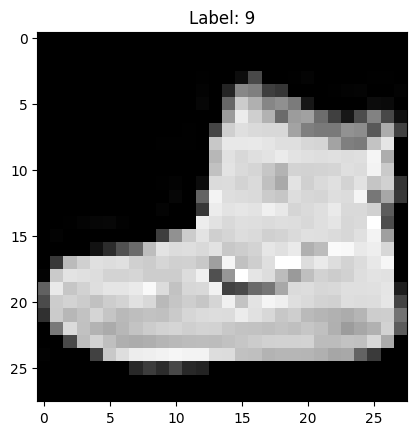

In [3]:
print(X_train.shape)  # (60000, 28, 28)
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

Step 4 — Preprocessing

In [4]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

STEP 5 — BUILD CNN

In [5]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 6 — Train Model

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8291 - loss: 0.4716 - val_accuracy: 0.8503 - val_loss: 0.4093
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8863 - loss: 0.3131 - val_accuracy: 0.8885 - val_loss: 0.3159
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9023 - loss: 0.2666 - val_accuracy: 0.8960 - val_loss: 0.2817
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9132 - loss: 0.2355 - val_accuracy: 0.9031 - val_loss: 0.2743
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9219 - loss: 0.2104 - val_accuracy: 0.9028 - val_loss: 0.2592


Step 7 — Evaluate

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9028 - loss: 0.2592
Test Accuracy: 0.9028000235557556


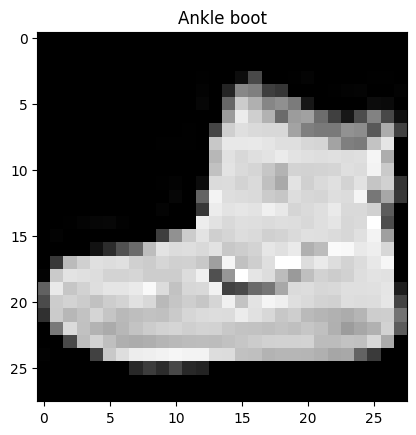

In [8]:
labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.imshow(X_train[0], cmap='gray')
plt.title(labels[y_train[0]])
plt.show()

Step 8 — Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


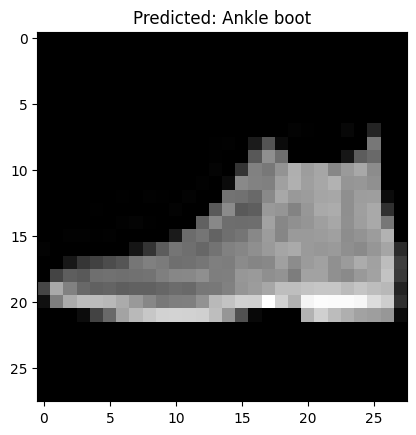

In [11]:
pred = model.predict(X_test)

plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {labels[np.argmax(pred[0])]}")
plt.show()

Step 9 — Accuracy Graph

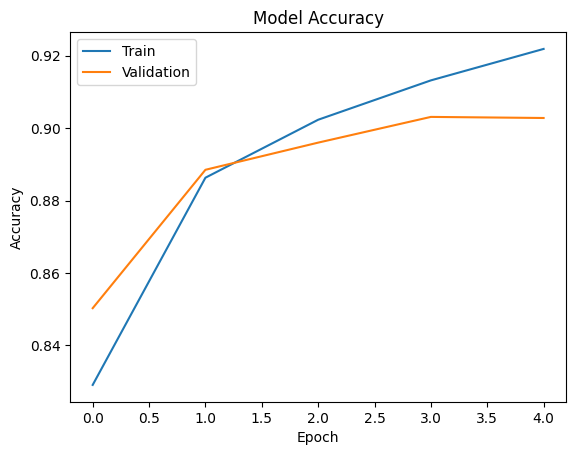

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

RESULT

The CNN model achieved high accuracy on the MNIST dataset and successfully classified handwritten digits.

CONCLUSION

CNN effectively extracted spatial features from image data and achieved strong performance in digit classification. It demonstrates the power of deep learning in image-based tasks.